In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df = pd.read_csv("vw_employee_performance.csv")
df.head()

,sk_employee,sk_time,name,month,year,total_achieved_task_count,avg_achievement_gap,avg_performance_percentage,total_working_hours,total_working_day,total_permission_day,total_absent_day,grade_code,months_of_service,is_overdue,next_grade_code,next_salary,next_promotion_duration
0,17,24,"Cinthia Manullang, S.H.",3,2025,0,5,94.68,8,1,0,0,GRD001,42,1,GRD002,5000000,24
1,58,69,Okto Prasasta,5,2025,0,3,96.88,8,1,0,0,GRD005,38,0,GRD005,15000000,60
2,33,42,Jamalia Nurdiyanti,4,2025,0,10,89.13,10,1,0,0,GRD001,99,1,GRD002,5000000,24
3,68,80,Belinda Sihombing,5,2025,1,0,100.00,9,1,0,0,GRD003,82,1,GRD004,12000000,48
4,34,43,"R. Oliva Oktaviani, S.T.",4,2025,0,1,98.85,8,1,0,0,GRD003,90,1,GRD004,12000000,48


In [ ]:
# df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))

In [ ]:
def forecast_variable(df, target_column, steps=3):
    if 'date' not in df.columns:
        df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
    df = df.sort_values('date')

    monthly = df.groupby('date')[target_column].mean().reset_index()
    monthly = monthly.rename(columns={target_column: f'avg_{target_column}'})
    ts = monthly.set_index('date')[f'avg_{target_column}']

    model = ARIMA(ts, order=(1, 1, 1))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=steps)
    future_dates = pd.date_range(start=ts.index[-1] + pd.offsets.MonthBegin(1), periods=steps, freq='MS')

    plt.figure(figsize=(10, 4))
    plt.plot(ts, label='Actual', color='blue', marker='o')
    plt.plot([ts.index[-1]] + list(future_dates), [ts.iloc[-1]] + list(forecast),
             label='Forecast', color='orange', linestyle='--', marker='x')
    plt.title(f'Forecast for {target_column}')
    plt.xlabel('Date')
    plt.ylabel(target_column)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return pd.Series(forecast.values, index=future_dates)

c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zer

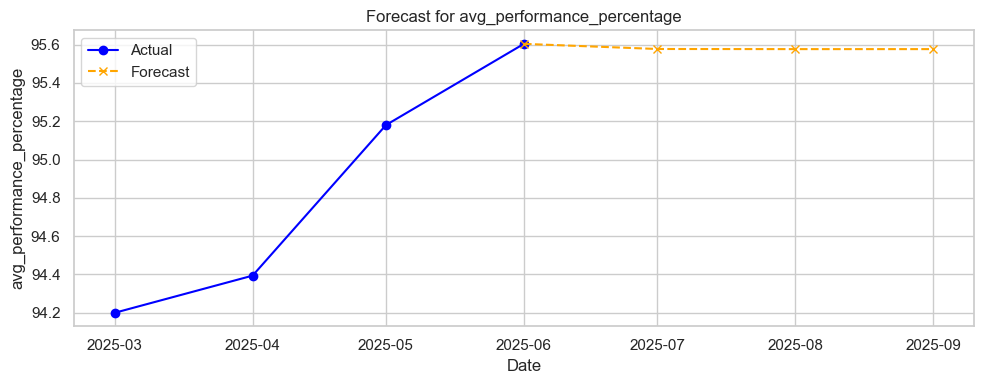

c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zer

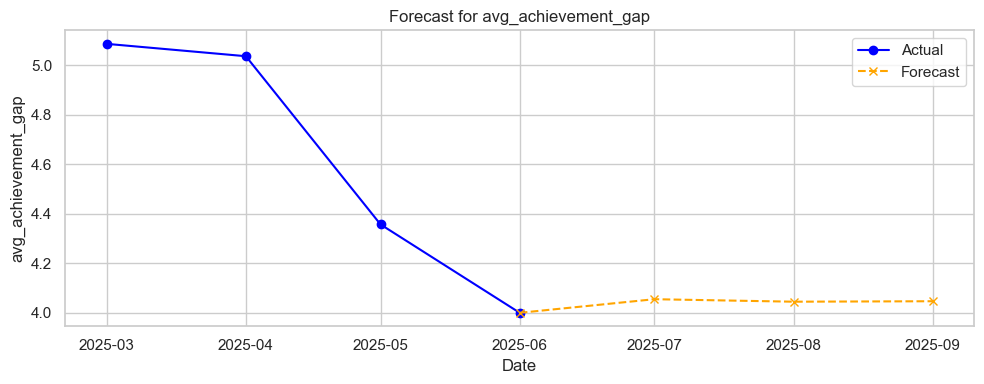

c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zer

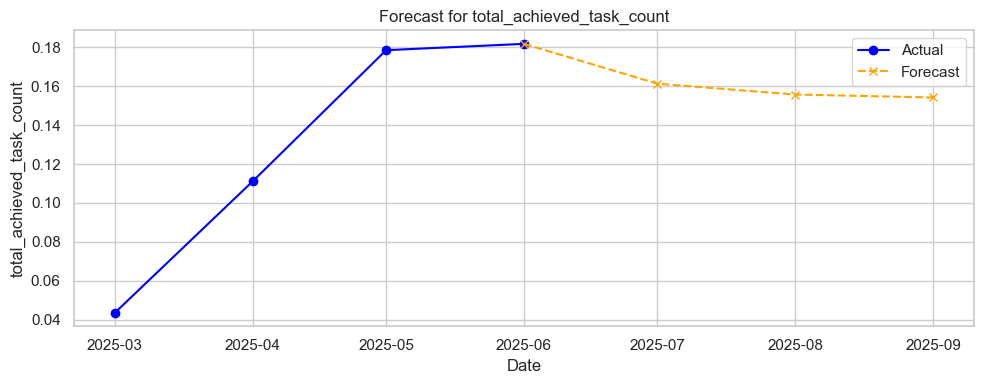

c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zer

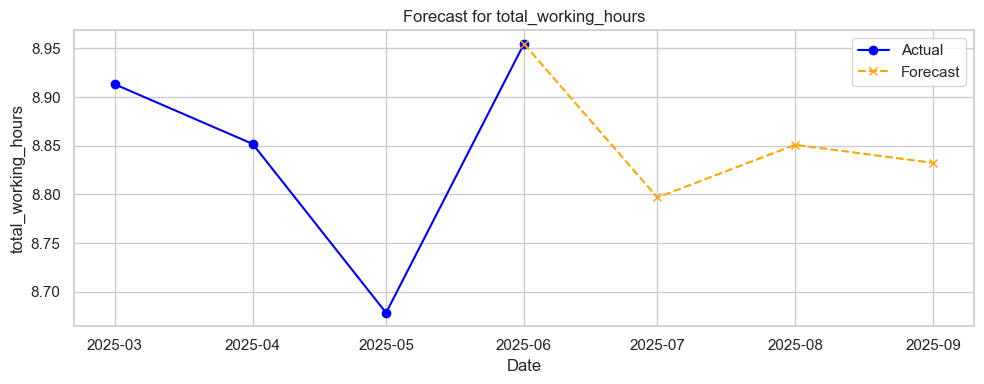

c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Dicky Zulfikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zer

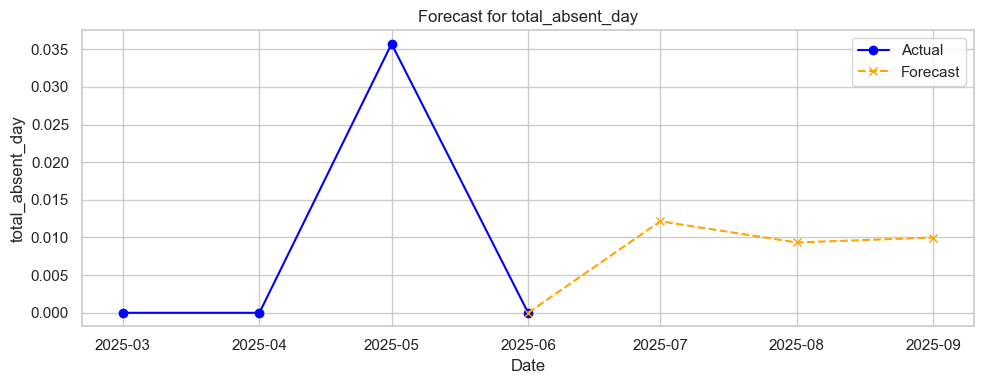

In [ ]:
forecast1 = forecast_variable(df, 'avg_performance_percentage')
forecast2 = forecast_variable(df, 'avg_achievement_gap')
forecast3 = forecast_variable(df, 'total_achieved_task_count')
forecast4 = forecast_variable(df, 'total_working_hours')
forecast5 = forecast_variable(df, 'total_absent_day')

In [ ]:
forecast_results = {
    'avg_performance_percentage': forecast1,
    'avg_achievement_gap': forecast2,
    'total_achieved_task_count': forecast3,
    'total_working_hours': forecast4,
    'total_absent_day': forecast5
}

for key, series in forecast_results.items():
    if series is None:
        raise ValueError(f"Forecast series for {key} is None!")
forecast_dates = forecast1.index

new_rows = []
for date in forecast_dates:
    row = {
        'month': date.month,
        'year': date.year,
        'date': date
    }
    for var_name, forecast_series in forecast_results.items():
        row[f'forecast_{var_name}'] = forecast_series.get(date, np.nan)
    new_rows.append(row)

forecast_df = pd.DataFrame(new_rows)
if 'date' not in df.columns:
    df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))

df_combined = pd.concat([df, forecast_df], ignore_index=True).reset_index(drop=True)
df_combined = df_combined.sort_values('date').reset_index(drop=True)
cols_map = {
    'forecast_avg_performance_percentage': 'avg_performance_percentage',
    'forecast_avg_achievement_gap': 'avg_achievement_gap',
    'forecast_total_achieved_task_count': 'total_achieved_task_count',
    'forecast_total_working_hours': 'total_working_hours',
    'forecast_total_absent_day': 'total_absent_day'
}

for forecast_col, actual_col in cols_map.items():
    df_combined[forecast_col] = df_combined[forecast_col].fillna(df_combined[actual_col])

In [60]:
df_combined.tail()

,sk_employee,sk_time,name,month,year,total_achieved_task_count,avg_achievement_gap,avg_performance_percentage,total_working_hours,total_working_day,...,is_overdue,next_grade_code,next_salary,next_promotion_duration,date,forecast_avg_performance_percentage,forecast_avg_achievement_gap,forecast_total_achieved_task_count,forecast_total_working_hours,forecast_total_absent_day
98,86.0,100.0,"Dt. Limar Usamah, S.Psi",6,2025,0.0,5.0,93.98,9.0,1.0,...,1.0,GRD003,8000000.0,36.0,2025-06-01,93.980000,5.000000,0.000000,9.000000,0.000000
99,79.0,93.0,Intan Wahyudin,6,2025,0.0,3.0,96.74,8.0,1.0,...,1.0,GRD005,15000000.0,60.0,2025-06-01,96.740000,3.000000,0.000000,8.000000,0.000000
100,NaN,NaN,NaN,7,2025,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2025-07-01,95.577711,4.054951,0.161326,8.796941,0.012150
101,NaN,NaN,NaN,8,2025,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2025-08-01,95.577071,4.044883,0.155751,8.850960,0.009341
102,NaN,NaN,NaN,9,2025,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2025-09-01,95.577056,4.046728,0.154234,8.832445,0.009990


In [62]:
data_cluster = pd.read_csv("hasil_cluster.csv")
data_cluster.head()

,sk_employee,sk_time,name,month,year,total_achieved_task_count,avg_achievement_gap,avg_performance_percentage,total_working_hours,total_working_day,total_permission_day,total_absent_day,grade_code,months_of_service,is_overdue,next_grade_code,next_salary,next_promotion_duration,cluster,cluster_label
0,17,24,"Cinthia Manullang, S.H.",3,2025,0,5,94.68,8,1,0,0,GRD001,42,1,GRD002,5000000,24,2,Baik
1,58,69,Okto Prasasta,5,2025,0,3,96.88,8,1,0,0,GRD005,38,0,GRD005,15000000,60,2,Baik
2,33,42,Jamalia Nurdiyanti,4,2025,0,10,89.13,10,1,0,0,GRD001,99,1,GRD002,5000000,24,0,Cukup
3,68,80,Belinda Sihombing,5,2025,1,0,100.00,9,1,0,0,GRD003,82,1,GRD004,12000000,48,1,Sangat Baik
4,34,43,"R. Oliva Oktaviani, S.T.",4,2025,0,1,98.85,8,1,0,0,GRD003,90,1,GRD004,12000000,48,0,Cukup


In [71]:
# Ambil hanya kolom 'name', 'cluster', dan 'label' dari data_cluster
data_cluster_filtered = data_cluster[['name', 'cluster', 'cluster_label']]

# Gabungkan dengan df_combined berdasarkan kolom 'name'
df_combined = pd.merge(df_combined, data_cluster_filtered, on='name', how='left')

In [73]:
df_combined.to_csv("data_cluster_forecast.csv")

In [75]:
df_combined.columns

Index(['sk_employee', 'sk_time', 'name', 'month', 'year',
       'total_achieved_task_count', 'avg_achievement_gap',
       'avg_performance_percentage', 'total_working_hours',
       'total_working_day', 'total_permission_day', 'total_absent_day',
       'grade_code', 'months_of_service', 'is_overdue', 'next_grade_code',
       'next_salary', 'next_promotion_duration', 'date',
       'forecast_avg_performance_percentage', 'forecast_avg_achievement_gap',
       'forecast_total_achieved_task_count', 'forecast_total_working_hours',
       'forecast_total_absent_day', 'cluster', 'cluster_label'],
      dtype='object')